# Instance Impact Framework: Full-Pipeline Case Study Notebook

## Overview

**The Pipeline** — A live end-to-end run on a Nepal flooding example: SAM3 building detection → Stage 2a exposure estimation → Stage 2b calibrated ensemble damage inference, with per-instance uncertainty visualization.

**Addendum — 2025 LA Wildfires** — Pre-computed results from applying the same pipeline across ~197 km² of LA County: 21,797 buildings assessed over 4 post-disaster acquisition dates using coverage-aware multi-date damage aggregation.

*A brief xView2 detection benchmark and data statement follow at the end.*

---

## Objective
This notebook executes and presents the **entire packaged pipeline** from raw pre/post input images to instance-level impact outputs.
You should expect per-building outputs from each stage: Stage 1 instance polygons with segmentation confidence, Stage 2a exposure signals (predicted population and building type), and Stage 2b damage predictions with calibrated confidence and uncertainty metrics.
The notebook culminates in a merged instance table, uncertainty-ranked cases, and polygon overlays that make each prediction interpretable in its visual context.

## Introduction
The increasing availability of high-resolution pre- and post-disaster satellite imagery has created new opportunities for automated, building-level damage assessment. However, many operational workflows still rely on either coarse area-level summaries or single-task predictions that do not jointly represent physical damage, exposure, and uncertainty at the building instance level. This gap limits practical use in time-critical scenarios such as emergency triage and post-event resource allocation.

This project introduces an **Instance Impact Framework** that produces building-level impact representations by integrating three complementary stages: (1) building instance extraction from imagery, (2) occupancy/exposure signal estimation, and (3) calibrated damage-state inference with uncertainty quantification. The framework is delivered as an end-to-end, reproducible inference pipeline and presentation notebook that can run on managed research platforms across CPU and GPU contexts.

To demonstrate applicability, this notebook executes a complete case study from input pre/post imagery to final interpretable outputs, including merged instance tables, uncertainty-ranked cases, and visual overlays. The system is designed to support both research reproducibility and operational interpretability through explicit stage outputs, confidence signals, and transparent intermediate artifacts.

## Theory of Impact
Building-level disaster response decisions require more than binary damaged/not-damaged maps. By representing each building instance with both **damage severity** and **exposure proxies** (e.g., estimated population/type), the framework enables more actionable prioritization, such as identifying locations with high expected impact and high uncertainty for human review.

This instance-centric approach supports practical workflows in emergency management, humanitarian logistics, and resilience planning by enabling: (a) targeted triage, (b) uncertainty-aware escalation, and (c) auditable evidence linking predictions to visual context. In this way, the framework shifts output from static classification toward decision-support-ready geospatial intelligence.

## Novelty
- **Instance-Centric Integration:** Rather than treating extraction, exposure estimation, and damage prediction as isolated tasks, we explicitly align them by shared `instance_id` and synthesize them into a unified building-level representation.
- **Operational Uncertainty:** Stage 2b includes calibrated probabilities and ensemble-derived uncertainty metrics (`pmax`, margin, entropy, expected-severity variance), supporting abstention and review workflows rather than overconfident automation.
- **Reusable Shared Artifacts:** Standardized per-instance pre/post crops and masks are generated once and reused across downstream stages, improving reproducibility and modular extensibility.
- **End-to-End Reproducible Delivery:** The packaged notebook and CLI pipeline provide a runnable path from imagery input to interpretable outputs, with explicit logging and stage-level sanity checks suitable for platform-constrained environments (CPU/GPU).

## Pipeline
`Stage1 -> shared subimages -> Stage2a -> Stage2b -> presentation -> overlays`

![Instance Impact Conceptualization](II-Conceptualization.png)

## Assumptions
- Dependencies are resolved automatically via the notebook's bootstrap cells (`.nb_vendor`); no manual environment setup is required beyond a compatible base kernel.
- Input pre/post images are valid and correspond to the same tile.
- The notebook is run top-to-bottom without skipping cells.
- A Hugging Face access token is required for Stage 1 (SAM3 is a gated model).

## Scope
- Inference + presentation only (no training).
- Structured for server-kernel execution with reproducible paths and commands.

## Reproducibility and Environment Strategy

This notebook is designed for top-down execution in managed research kernels where direct modification of the base environment may be restricted. To preserve reproducibility, dependencies are installed into a project-local directory (`.nb_vendor`) and injected into both notebook imports and subprocess-based stage scripts.

This strategy provides two practical benefits: (1) compatibility across CPU-only and GPU-enabled sessions on i-guide, and (2) isolation from user-site package drift that can otherwise break scientific dependencies. The next two code cells perform dependency bootstrap and import validation before any model stage begins.

## Methods: Execution Protocol

The pipeline is implemented as a staged experimental protocol where each stage emits explicit artifacts used by subsequent stages. The initial setup cells establish path conventions, dependency resolution, authentication, and runtime device configuration so that Stage 1 through Stage 2b can be executed and audited consistently.

Methodologically, this notebook follows a deterministic order: environment bootstrap -> stage execution -> stage-level sanity reporting -> final synthesis and uncertainty-driven interpretation.

## Model Specification (Run Configuration)

This case study uses the packaged inference stack exactly as configured in this notebook run.

- **Stage 1 (Instance Extraction):** SAM3 via `samgeo` + `transformers` backend, producing instance-level polygons and confidence from pre-disaster imagery.
- **Stage 2a (Exposure Proxy):** EfficientNet-B0-based 4-channel model (RGB + mask) for population-regression signal and building-type classification.
- **Stage 2b (Damage + Uncertainty):** Siamese ordinal CORAL-style damage inference, executed as a calibrated multi-checkpoint ensemble with uncertainty metrics (`pmax`, margin, entropy, expected-severity variance).
- **Calibration mode:** temperature scaling (packaged calibration directories applied during Stage 2b ensemble inference).
- **Checkpoint provenance:** model files are loaded from `II_package/models/` with configs in `II_package/configs/` and calibration artifacts in `II_package/calibration/`.

This section is intentionally concise; implementation-level details remain traceable in the stage scripts and companion technical logs.

In [1]:
from pathlib import Path
import os
import json
import shutil
import subprocess
import shlex
import sys
import importlib

# Resolve notebook directory robustly.
# Managed kernels (e.g., i-guide geoai) may have a stale or deleted cwd,
# so we prefer IPython's _dh (notebook launch dir) with cwd() as fallback.
try:
    _nb_dir = Path(globals()["_dh"][0])
except Exception:
    try:
        _nb_dir = Path.cwd()
    except Exception:
        _nb_dir = Path(os.environ.get("HOME", "/tmp"))

VENDOR = _nb_dir / ".nb_vendor"
VENDOR.mkdir(parents=True, exist_ok=True)

if str(VENDOR) not in sys.path:
    sys.path.insert(0, str(VENDOR))
importlib.invalidate_caches()
print("Using local vendor path:", VENDOR)
print("Base imports ready.")

Using local vendor path: /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/.nb_vendor
Base imports ready.


### Core Imports and Local Path Setup

Foundational Python modules are imported and the `.nb_vendor` overlay path is initialized. If `.nb_vendor` exists, it is prioritized in `sys.path` to ensure deterministic dependency resolution for this notebook run.

In [2]:
# Cell 1/2: detect-then-install notebook-local dependencies into .nb_vendor
#
# For packages where the base kernel has an older version that is insufficient,
# we check for the specific symbol or minimum version needed — not just importability.

if str(VENDOR) not in sys.path:
    sys.path.insert(0, str(VENDOR))
importlib.invalidate_caches()


def pip_install(*pkgs, no_deps=True):
    cmd = [sys.executable, "-m", "pip", "install", "--upgrade", "--target", str(VENDOR)]
    if no_deps:
        cmd.append("--no-deps")
    cmd.extend(pkgs)
    print("[cmd]", " ".join(cmd))
    subprocess.run(cmd, check=True)


def check_import(module_name):
    importlib.invalidate_caches()
    importlib.import_module(module_name)


def check_attr(module_name, attr_name):
    """Check that a module exposes a specific attribute (version-sensitive)."""
    importlib.invalidate_caches()
    mod = importlib.import_module(module_name)
    if not hasattr(mod, attr_name):
        raise ImportError(f"{module_name} missing '{attr_name}' (version too old: {getattr(mod, '__version__', '?')})")


def check_min_version(module_name, min_ver_tuple):
    """Check that module.__version__ >= min_ver_tuple, e.g. (2025, 10, 22)."""
    importlib.invalidate_caches()
    mod = importlib.import_module(module_name)
    ver_str = getattr(mod, "__version__", "0")
    ver_parts = tuple(int(x) for x in ver_str.split(".")[:len(min_ver_tuple)])
    if ver_parts < min_ver_tuple:
        raise ImportError(f"{module_name} {ver_str} < {'.'.join(map(str, min_ver_tuple))}")


def check_sam3model():
    importlib.invalidate_caches()
    from transformers import Sam3Model  # noqa: F401


def check_samgeo3():
    importlib.invalidate_caches()
    from samgeo import SamGeo3  # noqa: F401


def purge_modules(*prefixes):
    """Remove cached module entries so the next import picks up .nb_vendor.
    Only safe for pure-Python packages; native extensions (PyO3/Rust) like
    tokenizers, regex, safetensors cannot be re-initialized after unloading."""
    stale = [k for k in sys.modules if any(k == p or k.startswith(p + ".") for p in prefixes)]
    for k in stale:
        del sys.modules[k]
    importlib.invalidate_caches()


def ensure(pkg_spec, check_fn):
    try:
        check_fn()
        print(f"[skip] {pkg_spec} (already importable)")
        return "skipped"
    except Exception as e:
        print(f"[need] {pkg_spec} ({type(e).__name__}: {e})")
        pip_install(pkg_spec)
        importlib.invalidate_caches()
        return "installed"


results = []

# Core runtime packages (install only when checks fail).
results.append(("timm==1.0.25", ensure("timm==1.0.25", lambda: check_import("timm"))))
results.append(("opencv-python-headless==4.10.0.84", ensure("opencv-python-headless==4.10.0.84", lambda: check_import("cv2"))))
results.append(("segment-anything", ensure("segment-anything", lambda: check_import("segment_anything"))))
results.append(("segment-geospatial", ensure("segment-geospatial", check_samgeo3)))
results.append(("geoai-py", ensure("geoai-py", lambda: check_import("geoai"))))
results.append(("geopandas", ensure("geopandas", lambda: check_import("geopandas"))))

# Sam3Model support from transformers main.
results.append(("git+https://github.com/huggingface/transformers.git", ensure("git+https://github.com/huggingface/transformers.git", check_sam3model)))

# Explicit transitive/runtime deps — version-sensitive checks where base kernel is too old.
results.append(("httpx", ensure("httpx", lambda: check_import("httpx"))))
results.append(("httpcore", ensure("httpcore", lambda: check_import("httpcore"))))
results.append(("huggingface_hub>=0.30", ensure("huggingface_hub>=0.30", lambda: check_attr("huggingface_hub", "is_offline_mode"))))
results.append(("regex>=2025.10.22", ensure("regex>=2025.10.22", lambda: check_min_version("regex", (2025, 10, 22)))))
results.append(("tokenizers", ensure("tokenizers", lambda: check_min_version("tokenizers", (0, 20)))))
results.append(("safetensors", ensure("safetensors", lambda: check_min_version("safetensors", (0, 5)))))
results.append(("h11", ensure("h11", lambda: check_import("h11"))))
results.append(("anyio", ensure("anyio", lambda: check_import("anyio"))))
results.append(("sniffio", ensure("sniffio", lambda: check_import("sniffio"))))
results.append(("idna", ensure("idna", lambda: check_import("idna"))))
results.append(("certifi", ensure("certifi", lambda: check_import("certifi"))))

installed = sum(1 for _, s in results if s == "installed")
skipped = sum(1 for _, s in results if s == "skipped")

# Purge stale sys.modules entries for all packages that were installed into .nb_vendor.
# This ensures the NEXT cell's imports resolve from .nb_vendor, not from cached base-kernel modules.
if installed > 0:
    # Only purge pure-Python packages. Native extensions (tokenizers, regex,
    # safetensors) use PyO3/Rust and cannot be re-initialized after unloading.
    purge_modules(
        "transformers", "huggingface_hub",
        "samgeo", "geoai", "geopandas", "segment_anything",
        "timm", "cv2", "httpx", "httpcore",
        "h11", "anyio", "sniffio", "idna", "certifi",
    )
    print(f"Purged stale module cache for {installed} newly installed packages.")

print(f"Dependency pass complete. installed={installed}, skipped={skipped}, vendor={VENDOR}")

[need] timm==1.0.25 (ModuleNotFoundError: No module named 'timm')
[cmd] /cvmfs/iguide.purdue.edu/software/conda/geoai/bin/python -m pip install --upgrade --target /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/.nb_vendor --no-deps timm==1.0.25
  Using cached timm-1.0.25-py3-none-any.whl.metadata (38 kB)
Using cached timm-1.0.25-py3-none-any.whl (2.6 MB)
[need] opencv-python-headless==4.10.0.84 (ModuleNotFoundError: No module named 'cv2')
[cmd] /cvmfs/iguide.purdue.edu/software/conda/geoai/bin/python -m pip install --upgrade --target /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/.nb_vendor --no-deps opencv-python-headless==4.10.0.84
  Using cached opencv_python_headless-4.10.0.84-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
Using cached opencv_python_headless-4.10.0.84-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (49.9 MB)
[need] segment-anything (ModuleNotFoundError: No module named 'segment_anythin

  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-qabl3hb4


  Resolved https://github.com/huggingface/transformers.git to commit f8679cc352fb1f0171ebc92c7f5ad2ecd4819d09
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for transformers: filename=transformers-5.6.0.dev0-py3-none-any.whl size=11425325 sha256=f7c3df1b6240af48b4fc00ad057cc5f7e6f156305e5cbe1dd76d3445d7aab837
  Stored in directory: /tmp/pip-ephem-wheel-cache-me6d3fhw/wheels/32/4b/78/f195c684dd3a9ed21f3b39fe8f85b48df7918581b6437be143
Successfully built transformers
[need] httpx (ModuleNotFoundError: No module named 'httpx')
[cmd] /cvmfs/iguide.purdue.edu/software/conda/geoai/bin/python -m pip install --upgrade --target /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/.nb_v

  Resolved https://github.com/huggingface/transformers.git to commit 374d44d54adb1c5f52e68aff97d1675f56d657a8
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for transformers: filename=transformers-5.6.0.dev0-py3-none-any.whl size=11359394 sha256=0c453211bffb10e7a73b6474cdc21f62394d7ca3a17f8d1cef128d3e6f3028cb
  Stored in directory: /tmp/pip-ephem-wheel-cache-gfr06gb7/wheels/32/4b/78/f195c684dd3a9ed21f3b39fe8f85b48df7918581b6437be143
Successfully built transformers
[cmd] /cvmfs/iguide.purdue.edu/software/conda/geoai/bin/python -m pip install --upgrade --target /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/.nb_vendor --no-deps httpx
  Using cached httpx-0.28.1-py3-none-a

### Dependency Bootstrap

Notebook-local **detect-then-install** dependency setup targets `.nb_vendor`. Packages that are already importable with sufficient version are skipped, reducing rerun time while preserving reproducibility.

In [3]:
# Cell 2/2: validate imports from .nb_vendor
#
# Purge + re-import to guarantee we pick up .nb_vendor versions,
# not stale base-kernel modules cached in sys.modules during detection.

if str(VENDOR) not in sys.path:
    sys.path.insert(0, str(VENDOR))

# Only purge pure-Python packages; native extensions (tokenizers, regex,
# safetensors) use PyO3 and cannot be re-initialized in the same process.
purge_modules("transformers", "huggingface_hub",
              "samgeo", "geoai", "timm")

import timm
from transformers import Sam3Model
from samgeo import SamGeo3

print("Using vendor path:", VENDOR)
print("timm:", timm.__version__)
print("transformers:", __import__("transformers").__version__)
print("Sam3Model: OK")
print("SamGeo3: OK")

To use SamGeo 3, install it as:
	pip install segment-geospatial[samgeo3]
Using vendor path: /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/.nb_vendor
timm: 1.0.25
transformers: 5.6.0.dev0
Sam3Model: OK
SamGeo3: OK


### Dependency Validation

Critical imports (`timm`, `Sam3Model`, `SamGeo3`) are validated from the local environment before any model stage is executed.

In [4]:
# --- Token setup for Stage1 SAM3 access ---
# Stage 1 uses SAM3, a gated model on Hugging Face that requires authentication.
# To obtain a token: https://huggingface.co/settings/tokens (read-only is sufficient).
# You must also accept the SAM3 model license at https://huggingface.co/facebook/sam3.
import os
from getpass import getpass

if not os.environ.get("HF_TOKEN", "").strip():
    token = getpass("Enter HF_TOKEN (input hidden, leave blank to skip): ").strip()
    if token:
        os.environ["HF_TOKEN"] = token
        print("HF_TOKEN set for current kernel session.")
    else:
        print("HF_TOKEN not provided. Stage 1 may fail if SAM3 model access is required.")
else:
    print("HF_TOKEN already present in environment.")

Enter HF_TOKEN (input hidden, leave blank to skip):  ········


HF_TOKEN set for current kernel session.


### Model Access Token

Stage 1 requires authenticated access to SAM3, a gated model hosted on Hugging Face. This cell prompts for `HF_TOKEN` if one is not already set in the environment. A read-only token is sufficient. If you do not have a token, create one at [huggingface.co/settings/tokens](https://huggingface.co/settings/tokens) and accept the model license at [huggingface.co/facebook/sam3](https://huggingface.co/facebook/sam3).

In [5]:
# --- 1) Study configuration: full pipeline run ---

# Auto-locate package root using the same robust notebook-dir as VENDOR.
PACKAGE_ROOT = _nb_dir
if not (PACKAGE_ROOT / "run_pipeline.sh").exists() and (PACKAGE_ROOT / "II_package" / "run_pipeline.sh").exists():
    PACKAGE_ROOT = PACKAGE_ROOT / "II_package"

# Input image pair (customize these two paths).
PRE_IMAGE = PACKAGE_ROOT / "example_image_pair" / "nepal-flooding_00000408_pre_disaster.png"
POST_IMAGE = PACKAGE_ROOT / "example_image_pair" / "nepal-flooding_00000408_post_disaster.png"

# Run identifier for outputs.
RUN_ID = "nb_full_pipeline_nepal_flooding_00000408"

# Runtime settings (aligned with package defaults).
PYTHON_BIN = sys.executable
CUDA_VISIBLE_DEVICES = "0"
VERBOSE_RUN = False

print("PACKAGE_ROOT:", PACKAGE_ROOT)
print("PRE_IMAGE:", PRE_IMAGE)
print("POST_IMAGE:", POST_IMAGE)
print("RUN_ID:", RUN_ID)
print("PYTHON_BIN:", PYTHON_BIN)

PACKAGE_ROOT: /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package
PRE_IMAGE: /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/example_image_pair/nepal-flooding_00000408_pre_disaster.png
POST_IMAGE: /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/example_image_pair/nepal-flooding_00000408_post_disaster.png
RUN_ID: nb_full_pipeline_nepal_flooding_00000408
PYTHON_BIN: /cvmfs/iguide.purdue.edu/software/conda/geoai/bin/python


### Experiment Configuration

Case-study inputs and runtime identifiers (`PACKAGE_ROOT`, pre/post image paths, `RUN_ID`, Python executable) are defined here. These parameters govern artifact locations and reproducible reruns.

### Model Checkpoint Download

Model checkpoint files are hosted as GitHub Release assets to avoid Git LFS dependencies. This cell checks whether each checkpoint is present and valid locally; missing or stub files are downloaded automatically from the release.

In [6]:
# Download model checkpoints from GitHub Releases if missing or stub files.
import urllib.request

_RELEASE_BASE = (
    "https://github.com/jikun-tamu/Instance-Impact-IGUIDE-SpatialAIChallenge2026"
    "/releases/download/v1.0.0-alpha"
)

_MODEL_FILES = {
    "models/stage2a/stage2a_best_model.pt": f"{_RELEASE_BASE}/stage2a_best_model.pt",
    "models/stage2b/inference0.7273.pt": f"{_RELEASE_BASE}/stage2b_inference0.7273.pt",
    "models/stage2b/inference0.7066_seed9999.pt": f"{_RELEASE_BASE}/stage2b_inference0.7066_seed9999.pt",
    "models/stage2b/inference0.7034_seed7777.pt": f"{_RELEASE_BASE}/stage2b_inference0.7034_seed7777.pt",
}

_MIN_CKPT_SIZE = 1_000_000  # real checkpoints are >100MB; stubs/pointers are <4KB

for _rel_path, _url in _MODEL_FILES.items():
    _local = PACKAGE_ROOT / _rel_path
    _local.parent.mkdir(parents=True, exist_ok=True)
    if _local.exists() and _local.stat().st_size > _MIN_CKPT_SIZE:
        print(f"[ok]   {_rel_path}  ({_local.stat().st_size / 1e6:.1f} MB)")
        continue
    _reason = "missing" if not _local.exists() else f"stub ({_local.stat().st_size} bytes)"
    print(f"[download] {_rel_path}  ({_reason})")
    print(f"  <- {_url}")
    urllib.request.urlretrieve(_url, str(_local))
    if _local.stat().st_size < _MIN_CKPT_SIZE:
        raise RuntimeError(f"Download failed or file too small: {_local} ({_local.stat().st_size} bytes)")
    print(f"  done ({_local.stat().st_size / 1e6:.1f} MB)")

print("\nAll model checkpoints verified.")

[download] models/stage2a/stage2a_best_model.pt  (missing)
  <- https://github.com/jikun-tamu/Instance-Impact-IGUIDE-SpatialAIChallenge2026/releases/download/v1.0.0-alpha/stage2a_best_model.pt
  done (19.5 MB)
[download] models/stage2b/inference0.7273.pt  (missing)
  <- https://github.com/jikun-tamu/Instance-Impact-IGUIDE-SpatialAIChallenge2026/releases/download/v1.0.0-alpha/stage2b_inference0.7273.pt
  done (371.8 MB)
[download] models/stage2b/inference0.7066_seed9999.pt  (missing)
  <- https://github.com/jikun-tamu/Instance-Impact-IGUIDE-SpatialAIChallenge2026/releases/download/v1.0.0-alpha/stage2b_inference0.7066_seed9999.pt
  done (371.8 MB)
[download] models/stage2b/inference0.7034_seed7777.pt  (missing)
  <- https://github.com/jikun-tamu/Instance-Impact-IGUIDE-SpatialAIChallenge2026/releases/download/v1.0.0-alpha/stage2b_inference0.7034_seed7777.pt
  done (371.8 MB)

All model checkpoints verified.


In [7]:
# --- 2) Prepare a clean run directory ---
# This cell keeps runtime setup deterministic by resetting the run folder.

RUN_ROOT = PACKAGE_ROOT / "outputs" / "driver_runs"
RUN_ROOT.mkdir(parents=True, exist_ok=True)
RUN_DIR = RUN_ROOT / RUN_ID
if RUN_DIR.exists():
    shutil.rmtree(RUN_DIR)
print("RUN_DIR (fresh):", RUN_DIR)

RUN_DIR (fresh): /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408


### Output Workspace Reset

A fresh run directory is created for the current `RUN_ID`, ensuring that outputs correspond only to the present execution and not stale artifacts from prior runs.

In [8]:
# --- 2b) Scientific/runtime imports + device selection ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

STAGE1_DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
STAGE_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("numpy:", np.__version__)
print("numpy path:", np.__file__)
print("torch:", torch.__version__)
print("cuda_available:", torch.cuda.is_available(), "count:", torch.cuda.device_count())
print("STAGE1_DEVICE:", STAGE1_DEVICE)
print("STAGE_DEVICE:", STAGE_DEVICE)
print("Scientific imports ready.")

numpy: 1.26.4
numpy path: /cvmfs/iguide.purdue.edu/software/conda/geoai/lib/python3.11/site-packages/numpy/__init__.py
torch: 2.4.0
cuda_available: False count: 0
STAGE1_DEVICE: cpu
STAGE_DEVICE: cpu
Scientific imports ready.


## Stage 1: Building Instance Extraction

Stage 1 detects and delineates building instances from the pre-disaster image, then exports instance-level polygons and confidence scores used as anchors for downstream modeling. This stage defines the shared unit of analysis (`instance_id`) for the full framework.

Expected logs include `HF_TOKEN` notices, SamGeo package hints, and raster non-georeferenced warnings; these are normal for this PNG/pixel-space workflow. On CPU-only sessions, Stage 1 commonly requires approximately 8-15 minutes for one image under this notebook configuration.

In [9]:
# --- 3a) Stage 1: execute ---

env = dict(os.environ)
env["PYTHON_BIN"] = PYTHON_BIN
env["CUDA_VISIBLE_DEVICES"] = CUDA_VISIBLE_DEVICES
# Ensure stage subprocesses can resolve notebook-local vendor packages.
if VENDOR.exists():
    existing_pp = env.get("PYTHONPATH", "")
    env["PYTHONPATH"] = str(VENDOR) + ((":" + existing_pp) if existing_pp else "")

def run_step(cmd, title):
    print(f"\n===== {title} =====")
    print("[cmd]", " ".join(shlex.quote(str(x)) for x in cmd))
    subprocess.run([str(x) for x in cmd], check=True, cwd=str(PACKAGE_ROOT), env=env)

tile_id = PRE_IMAGE.stem
if tile_id.endswith("_pre_disaster"):
    tile_id = tile_id[: -len("_pre_disaster")]

pair_dir = RUN_DIR / "pair_inputs"
pair_dir.mkdir(parents=True, exist_ok=True)
pre_link = pair_dir / f"{tile_id}_pre_disaster.png"
post_link = pair_dir / f"{tile_id}_post_disaster.png"
for dst in [pre_link, post_link]:
    if dst.exists() or dst.is_symlink():
        dst.unlink()
pre_link.symlink_to(PRE_IMAGE.resolve())
post_link.symlink_to(POST_IMAGE.resolve())

stage1_out = RUN_DIR / "stage1"
shared_out = RUN_DIR / "shared_instances_r48"
stage2a_input_csv = RUN_DIR / "stage2a_infer_input.csv"
stage2a_out_csv = RUN_DIR / "stage2a_predictions.csv"
stage2b_out_jsonl = RUN_DIR / "stage2b_ensemble.jsonl"
presented_csv = RUN_DIR / "instance_results_presented.csv"
uncertain_csv = RUN_DIR / "instance_results_top_uncertain.csv"
vis_dir = RUN_DIR / "vis_instance_level"

run_step(
    [
        PYTHON_BIN,
        PACKAGE_ROOT / "stage1/SAM3_Final_20260226/scripts/run_sam3_building_infer.py",
        "--input", pair_dir,
        "--output", stage1_out,
        "--pattern", f"{tile_id}_pre_disaster.png",
        "--max-images", "1",
        "--prompt", "building",
        "--min-size", "30",
        "--output-style", "notebook",
        "--batch-size", "1",
        "--device", STAGE1_DEVICE,
        "--backend", "transformers",
        "--tile-size", "512",
        "--overlap", "64",
    ],
    "Stage 1: Building Instance Extraction",
)

label_dir = stage1_out / "labels"


===== Stage 1: Building Instance Extraction =====
[cmd] /cvmfs/iguide.purdue.edu/software/conda/geoai/bin/python /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/stage1/SAM3_Final_20260226/scripts/run_sam3_building_infer.py --input /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/pair_inputs --output /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/stage1 --pattern nepal-flooding_00000408_pre_disaster.png --max-images 1 --prompt building --min-size 30 --output-style notebook --batch-size 1 --device cpu --backend transformers --tile-size 512 --overlap 64


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


To use SamGeo 3, install it as:
	pip install segment-geospatial[samgeo3]
torch_version: 2.4.0
cuda_available: False
cuda_device_count: 0
Using cpu device and transformers backend


Loading weights: 100%|██████████| 1468/1468 [00:02<00:00, 494.07it/s]
/cvmfs/iguide.purdue.edu/software/conda/geoai/lib/python3.11/site-packages/rasterio/__init__.py:304: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/cvmfs/iguide.purdue.edu/software/conda/geoai/lib/python3.11/site-packages/rasterio/__init__.py:314: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(
/cvmfs/iguide.purdue.edu/software/conda/geoai/lib/python3.11/site-packages/rasterio/__init__.py:314: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


Found 34 objects.
Saved 34 mask(s) to /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/stage1/.tmp_tiles/masks/nepal-flooding_00000408_pre_disaster_x0_y0_w512_h512.tif
Saved confidence scores to /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/stage1/.tmp_tiles/masks/nepal-flooding_00000408_pre_disaster_x0_y0_w512_h512_scores.tif
Found 14 objects.
Saved 14 mask(s) to /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/stage1/.tmp_tiles/masks/nepal-flooding_00000408_pre_disaster_x448_y0_w512_h512.tif
Saved confidence scores to /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/stage1/.tmp_tiles/masks/nepal-flooding_00000408_pre_disaster_x448_y0_w512_h512_scores.tif
No o

To use SamGeo 3, install it as:
	pip install segment-geospatial[samgeo3]
torch_version: 2.4.0
cuda_available: False
cuda_device_count: 0
Using cpu device and transformers backend


Loading weights: 100%|██████████| 1468/1468 [00:02<00:00, 719.71it/s]
/cvmfs/iguide.purdue.edu/software/conda/geoai/lib/python3.11/site-packages/rasterio/__init__.py:304: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/cvmfs/iguide.purdue.edu/software/conda/geoai/lib/python3.11/site-packages/rasterio/__init__.py:314: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(
/cvmfs/iguide.purdue.edu/software/conda/geoai/lib/python3.11/site-packages/rasterio/__init__.py:314: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


Found 34 objects.
Saved 34 mask(s) to /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/stage1/.tmp_tiles/masks/nepal-flooding_00000408_pre_disaster_x0_y0_w512_h512.tif
Saved confidence scores to /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/stage1/.tmp_tiles/masks/nepal-flooding_00000408_pre_disaster_x0_y0_w512_h512_scores.tif
Found 14 objects.
Saved 14 mask(s) to /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/stage1/.tmp_tiles/masks/nepal-flooding_00000408_pre_disaster_x448_y0_w512_h512.tif
Saved confidence scores to /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/stage1/.tmp_tiles/masks/nepal-flooding_00000408_pre_disaster_x448_y0_w512_h512_scores.tif
No o

### Stage 1 Sanity Report

Stage 1 completion is confirmed by checking expected summary artifacts and counting generated instance-level label outputs.

In [10]:
# --- 3b) Stage 1: report ---
stage1_summary = stage1_out / "run_summary.json"
print("[stage1] run_summary_exists=", stage1_summary.exists())
print("[stage1] label_json_count=", len(list(label_dir.glob("*_prediction.json"))) )

[stage1] run_summary_exists= True
[stage1] label_json_count= 1


### Result Discussion: Stage 1 Outputs

Stage 1 completed successfully and produced instance-level outputs required by the remainder of the pipeline. The artifact checks in this section confirm that label JSON generation and summary logging are present and internally consistent.

### Shared Instance Artifact Generation

Stage 1 outputs are transformed into standardized per-instance pre/post crops and masks (256×256, with mask M and ring R) used by both Stage 2a and Stage 2b.

In [11]:
# --- 4a) Shared subimages: execute ---
run_step(
    [
        PYTHON_BIN,
        PACKAGE_ROOT / "scripts/generate_shared_instance_subimages.py",
        "--stage1_labels_dir", label_dir,
        "--pre_images_dir", pair_dir,
        "--post_images_dir", pair_dir,
        "--out_root", shared_out,
        "--crop_size", "256",
        "--ring_radius_px", "48",
        "--strict_images",
        "--num_workers", "4",
        "--chunk_size", "100",
        "--log_every", "50",
    ],
    "Shared Subimage Generation",
)

shared_csv = shared_out / "shared_instance_samples.csv"

# Expected runtime: ~150 seconds


===== Shared Subimage Generation =====
[cmd] /cvmfs/iguide.purdue.edu/software/conda/geoai/bin/python /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/scripts/generate_shared_instance_subimages.py --stage1_labels_dir /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/stage1/labels --pre_images_dir /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/pair_inputs --post_images_dir /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/pair_inputs --out_root /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/shared_instances_r48 --crop_size 256 --ring_radius_px 48 --strict_images --num_workers 4 --chunk_size 100 --log_every 50
Found Stage-1 label json files: 

## Data and Split Protocol (Notebook Scope vs. Training Scope)

This notebook is a **single-pair inference case study** designed to demonstrate end-to-end execution and interpretation. It does not perform model training or re-estimate train/validation/test metrics.

- **Notebook scope:** pre/post pair -> instance extraction -> shared artifacts -> Stage 2a/2b inference -> synthesis and visualization.
- **Artifact schema:** instance-linked rows in `shared_instance_samples.csv` connect Stage 1 geometry/confidence with Stage 2a and Stage 2b outputs.
- **Split methodology context:** tile-blocked training/evaluation design and broader model-development protocols are documented in `Stage2b.md` and associated training scripts.

Interpret this notebook's results as case-level operational evidence, not as a replacement for aggregate benchmark reporting.

## AI-Ready Data and Metadata

The shared artifact stage converts Stage 1 outputs into a standardized instance table (`shared_instance_samples.csv`) that links each building to pre/post crops and binary masks. This table serves as the common input contract for both Stage 2a and Stage 2b, ensuring geometric and identity consistency across downstream models.

Metadata propagated through the pipeline includes tile and event identifiers, per-instance unique identifiers, and Stage 1 segmentation confidence scores. These are augmented progressively by Stage 2a exposure outputs and Stage 2b calibrated uncertainty metrics as the pipeline advances.

During artifact generation, instances with malformed polygon geometries (reported as `bad_wkt` exclusions) are filtered out. This is an intentional quality gate: skipping geometrically invalid instances improves downstream robustness at the cost of minor coverage reduction.

In [12]:
# --- 4b) Shared subimages: report ---
df_shared = pd.read_csv(shared_csv)
print("[shared] rows=", len(df_shared))
if "sam3_confidence" in df_shared.columns:
    x = pd.to_numeric(df_shared["sam3_confidence"], errors="coerce").dropna()
    if len(x) > 0:
        print("[shared] sam3_confidence median=", round(float(np.median(x)), 4))

[shared] rows= 113
[shared] sam3_confidence median= 0.6145


## Stage 2: Exposure and Damage Inference

Stage 2a estimates exposure-related signals (building type and population proxy) from shared instance crops, while Stage 2b predicts calibrated damage state and uncertainty from paired pre/post evidence. Together, these components provide complementary views of potential impact: who/what may be exposed and how severely structures appear affected.

In [13]:
# --- 5a) Stage 2a: execute ---
run_step(
    [
        PYTHON_BIN,
        PACKAGE_ROOT / "scripts/build_stage2a_infer_csv.py",
        "--shared_csv", shared_csv,
        "--out_csv", stage2a_input_csv,
        "--crop_col", "pre_crop",
        "--mask_col", "mask_M",
    ],
    "Stage 2a: Build Inference CSV",
)

run_step(
    [
        PYTHON_BIN,
        PACKAGE_ROOT / "scripts/infer_stage2a.py",
        "--input_csv", stage2a_input_csv,
        "--ckpt", PACKAGE_ROOT / "models/stage2a/stage2a_best_model.pt",
        "--out_csv", stage2a_out_csv,
        "--batch_size", "4",
        "--num_workers", "4",
        "--device", STAGE_DEVICE,
        "--print_examples", "5",
    ],
    "Stage 2a: Population/Type Inference",
)

df_s2a = pd.read_csv(stage2a_out_csv)


===== Stage 2a: Build Inference CSV =====
[cmd] /cvmfs/iguide.purdue.edu/software/conda/geoai/bin/python /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/scripts/build_stage2a_infer_csv.py --shared_csv /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/shared_instances_r48/shared_instance_samples.csv --out_csv /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/stage2a_infer_input.csv --crop_col pre_crop --mask_col mask_M
[done] input_rows= 113
[done] output_rows= 113
[done] skipped_missing_paths= 0
[done] wrote= /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/stage2a_infer_input.csv

===== Stage 2a: Population/Type Inference =====
[cmd] /cvmfs/iguide.purdue.edu/software/conda/geoai/bin/python /home/jovyan/Instance-Impact-IGUI

/home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/scripts/infer_stage2a.py:152: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path, map

[info] rows: 113
[info] device: cpu
[info] ckpt: /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/models/stage2a/stage2a_best_model.pt
[infer_stage2a] step=20/29 done_rows=80
[done] wrote: /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/stage2a_predictions.csv
[done] rows: 113
[summary] class_counts: {'commercial': 68, 'institutional': 45}
[summary] pred_population quantiles p0/p25/p50/p75/p95/p99: [44.565, 435.571, 851.511, 1279.746, 2440.444, 2961.628]
[examples] first_5:
   727957a8-ed83-4b47-8e28-3efd70d5a164 pop= 416.048 type= commercial conf= 0.521
   2b5f0eac-e652-4fad-a425-aa873544c34f pop= 116.156 type= institutional conf= 0.5236
   73735a83-d131-4aa1-9fa7-1071ccb32644 pop= 2682.652 type= commercial conf= 0.8535
   2f8fdbd9-dbf1-4fd2-9aaa-818ab45c890a pop= 724.188 type= commercial conf= 0.529
   07181554-41c4-461d-9279-2634787ff764 pop= 1786.849 type= commercial conf= 0.7615

[info] rows: 113
[info] device: cpu
[info] ckpt: /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/models/stage2a/stage2a_best_model.pt
[infer_stage2a] step=20/29 done_rows=80
[done] wrote: /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/stage2a_predictions.csv
[done] rows: 113
[summary] class_counts: {'commercial': 68, 'institutional': 45}
[summary] pred_population quantiles p0/p25/p50/p75/p95/p99: [44.565, 435.571, 851.511, 1279.746, 2440.444, 2961.628]
[examples] first_5:
   3ae8fcc2-18f8-4625-b6ba-d7f822d2f3fd pop= 416.048 type= commercial conf= 0.521
   37119ddc-0671-42ef-86b1-5b30c38bd50f pop= 116.156 type= institutional conf= 0.5236
   06fb46c3-ab33-42a6-aae8-ba3a74d021f2 pop= 2682.652 type= commercial conf= 0.8535
   2c2c33e2-8d71-45ae-a7ea-d143c5480a3e pop= 724.188 type= commercial conf= 0.529
   58c4ab68-7a63-49e0-b32a-67fd27872ffc pop= 1786.849 type= commercial conf= 0.7615

### Stage 2a Summary Statistics

Stage 2a output coverage and compact distribution diagnostics (building-type counts and population-proxy quantiles) are reported below.

In [14]:
# --- 5b) Stage 2a: report ---
print("[stage2a] rows=", len(df_s2a))
if "pred_type_class" in df_s2a.columns:
    print("[stage2a] type_counts=", df_s2a["pred_type_class"].value_counts().to_dict())
if "pred_population" in df_s2a.columns:
    p = pd.to_numeric(df_s2a["pred_population"], errors="coerce").dropna()
    if len(p) > 0:
        q = np.percentile(p, [50, 90, 99])
        print(f"[stage2a] population p50/p90/p99 = {q[0]:.2f}/{q[1]:.2f}/{q[2]:.2f}")

[stage2a] rows= 113
[stage2a] type_counts= {'commercial': 68, 'institutional': 45}
[stage2a] population p50/p90/p99 = 851.51/1780.95/2961.63


Stage 2a completed for all generated instances and returned a concentrated class mix with broad population-proxy spread. This suggests the model is producing differentiated exposure estimates rather than a narrow constant output.

Because Stage 2a is used here as an exposure signal, these values are best interpreted comparatively within the same run (higher vs. lower relative exposure) rather than as census-grade absolute counts.

### Stage 2b Ensemble Execution

Calibrated ensemble damage inference is executed below, computing per-instance uncertainty metrics (`pmax`, margin, entropy, variance of expected severity).

In [15]:
# --- 6a) Stage 2b: execute ---
run_step(
    [
        PYTHON_BIN,
        PACKAGE_ROOT / "scripts/infer_stage2_ensemble.py",
        "--csv", shared_csv,
        "--ckpts", "models/stage2b/inference0.7273.pt,models/stage2b/inference0.7066_seed9999.pt,models/stage2b/inference0.7034_seed7777.pt",
        "--configs", "configs/stage2b/run019_seed2025_train_config.json,configs/stage2b/seed9999_train_config.json,configs/stage2b/seed7777_train_config.json",
        "--weights", "4,3,2",
        "--calibration_dirs", "calibration/calibration_run019_r48,calibration/calibration_seed9999_r48,calibration/calibration_seed7777_r48",
        "--calibration_method", "temperature",
        "--out_jsonl", stage2b_out_jsonl,
        "--batch_size", "2",
        "--num_workers", "4",
        "--device", STAGE_DEVICE,
        "--print_examples", "5",
        "--log_every_steps", "20",
    ],
    "Stage 2b: Damage/Uncertainty Inference",
)

rows_s2b = []
with stage2b_out_jsonl.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            rows_s2b.append(json.loads(line))


===== Stage 2b: Damage/Uncertainty Inference =====
[cmd] /cvmfs/iguide.purdue.edu/software/conda/geoai/bin/python /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/scripts/infer_stage2_ensemble.py --csv /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/shared_instances_r48/shared_instance_samples.csv --ckpts models/stage2b/inference0.7273.pt,models/stage2b/inference0.7066_seed9999.pt,models/stage2b/inference0.7034_seed7777.pt --configs configs/stage2b/run019_seed2025_train_config.json,configs/stage2b/seed9999_train_config.json,configs/stage2b/seed7777_train_config.json --weights 4,3,2 --calibration_dirs calibration/calibration_run019_r48,calibration/calibration_seed9999_r48,calibration/calibration_seed7777_r48 --calibration_method temperature --out_jsonl /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/st

/home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/scripts/infer_stage2_ensemble.py:134: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(c

Loaded rows: 113
Device: cpu
Weights: [4.0, 3.0, 2.0]
Checkpoints:
 - models/stage2b/inference0.7273.pt
 - models/stage2b/inference0.7066_seed9999.pt
 - models/stage2b/inference0.7034_seed7777.pt
Configs:
 - configs/stage2b/run019_seed2025_train_config.json
 - configs/stage2b/seed9999_train_config.json
 - configs/stage2b/seed7777_train_config.json
Calibration method: temperature
Calibration dirs:
 - calibration/calibration_run019_r48
 - calibration/calibration_seed9999_r48
 - calibration/calibration_seed7777_r48
[example 1] event= tile=nepal-flooding_00000408 y_true=-1 y_pred=2
  model1 logits_cum=[5.7586, 6.2573, -6.3325] probs=[0.0031, 0.0, 0.9951, 0.0018] probs_cal=[0.0215, 0.0, 0.9636, 0.0148]
  model2 logits_cum=[4.5244, 4.516, -3.6273] probs=[0.0107, 0.0001, 0.9633, 0.0259] probs_cal=[0.045, 0.0002, 0.8753, 0.0795]
  model3 logits_cum=[4.4419, 1.5596, -3.7843] probs=[0.0116, 0.1621, 0.8041, 0.0222] probs_cal=[0.0153, 0.1729, 0.7837, 0.0281]
  ensemble logits_cum=[5.0546, 4.6329, 

Loaded rows: 113
Device: cpu
Weights: [4.0, 3.0, 2.0]
Checkpoints:
 - models/stage2b/inference0.7273.pt
 - models/stage2b/inference0.7066_seed9999.pt
 - models/stage2b/inference0.7034_seed7777.pt
Configs:
 - configs/stage2b/run019_seed2025_train_config.json
 - configs/stage2b/seed9999_train_config.json
 - configs/stage2b/seed7777_train_config.json
Calibration method: temperature
Calibration dirs:
 - calibration/calibration_run019_r48
 - calibration/calibration_seed9999_r48
 - calibration/calibration_seed7777_r48
[example 1] event= tile=nepal-flooding_00000408 y_true=-1 y_pred=2
  model1 logits_cum=[5.7586, 6.2573, -6.3325] probs=[0.0031, 0.0, 0.9951, 0.0018] probs_cal=[0.0215, 0.0, 0.9636, 0.0148]
  model2 logits_cum=[4.5244, 4.516, -3.6273] probs=[0.0107, 0.0001, 0.9633, 0.0259] probs_cal=[0.045, 0.0002, 0.8753, 0.0795]
  model3 logits_cum=[4.4419, 1.5596, -3.7843] probs=[0.0116, 0.1621, 0.8041, 0.0222] probs_cal=[0.0153, 0.1729, 0.7837, 0.0281]
  ensemble logits_cum=[5.0546, 4.6329, 

### Stage 2b Sanity Report

Quick diagnostics on Stage 2b outputs are provided below, including row counts, predicted damage-class distribution, and aggregate confidence behavior.

In [16]:
# --- 6b) Stage 2b: report ---
print("[stage2b] rows_jsonl=", len(rows_s2b))
if rows_s2b:
    y_counts = pd.Series([str(r.get("y_pred_ensemble", "")) for r in rows_s2b]).value_counts().to_dict()
    print("[stage2b] damage_pred_counts=", y_counts)
    pmax_vals = [float(r.get("pmax", np.nan)) for r in rows_s2b]
    pmax_vals = [v for v in pmax_vals if np.isfinite(v)]
    if pmax_vals:
        print("[stage2b] pmax mean=", round(float(np.mean(pmax_vals)), 4))

[stage2b] rows_jsonl= 113
[stage2b] damage_pred_counts= {'2': 94, '1': 10, '0': 6, '3': 3}
[stage2b] pmax mean= 0.8513


Stage 2b produced full-row predictions with a dominant share in one damage class and a strong average `pmax`, indicating confident classification for many instances in this tile. At the same time, sample-level entropy and variance outputs show non-trivial uncertainty in selected cases.

This dual behavior is expected and desirable: confident predictions for clear examples, alongside explicit uncertainty signals for ambiguous instances.

## Stage 3: Instance-Level Synthesis and Interpretation

This stage merges Stage 1, Stage 2a, and Stage 2b outputs by shared instance identity, producing a unified instance table and uncertainty-ranked cases for review. Visualization overlays link quantitative predictions back to local image evidence, improving interpretability and supporting human-in-the-loop triage.

In [17]:
# --- 7a) Synthesis + visualization: execute ---
run_step(
    [
        PYTHON_BIN,
        PACKAGE_ROOT / "scripts/present_instance_results.py",
        "--shared_csv", shared_csv,
        "--stage2a_csv", stage2a_out_csv,
        "--stage2b_jsonl", stage2b_out_jsonl,
        "--out_csv", presented_csv,
        "--out_top_uncertain_csv", uncertain_csv,
        "--top_k_uncertain", "30",
        "--print_top_n", "15",
    ],
    "Synthesis: Instance-Level Presentation",
)

run_step(
    [
        PYTHON_BIN,
        PACKAGE_ROOT / "scripts/visualize_stage2_overlays.py",
        "--pred_jsonl", stage2b_out_jsonl,
        "--csv", shared_csv,
        "--stage2a_csv", stage2a_out_csv,
        "--out_dir", vis_dir,
        "--max_outputs", "100",
        "--fill_opacity", "0.5",
    ],
    "Visualization: Instance Overlays",
)

print("\n[done] run_dir:", RUN_DIR)
print("[done] stage1_out:", stage1_out)
print("[done] shared_csv:", shared_csv)
print("[done] stage2a_out:", stage2a_out_csv)
print("[done] stage2b_out:", stage2b_out_jsonl)
print("[done] presented_csv:", presented_csv)
print("[done] top_uncertain_csv:", uncertain_csv)
print("[done] vis_dir:", vis_dir)


===== Synthesis: Instance-Level Presentation =====
[cmd] /cvmfs/iguide.purdue.edu/software/conda/geoai/bin/python /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/scripts/present_instance_results.py --shared_csv /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/shared_instances_r48/shared_instance_samples.csv --stage2a_csv /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/stage2a_predictions.csv --stage2b_jsonl /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/stage2b_ensemble.jsonl --out_csv /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChallenge2026/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/instance_results_presented.csv --out_top_uncertain_csv /home/jovyan/Instance-Impact-IGUIDE-SpatialAIChalle

## Output Interpretation and Responsible Use

The synthesis stage produces an instance-level table suitable for prioritization (e.g., high damage with high exposure) and an uncertainty-ranked list for human review. Overlay visualizations provide localized evidence to support interpretability.

Predictions should be treated as decision-support signals rather than definitive truth, especially under distribution shift or low-confidence conditions. Operational usage should retain human-in-the-loop validation for high-stakes decisions.

In [18]:
# --- 7b) Synthesis: report/load ---
df = pd.read_csv(presented_csv)
df_unc = pd.read_csv(uncertain_csv)
print("rows presented:", len(df))
print("rows uncertain:", len(df_unc))

rows presented: 113
rows uncertain: 30


### Consolidated Summary Table

Final joined counts and high-level categorical summaries across all pipeline stages are printed below for rapid interpretation.

In [19]:
# --- 8) Final synthesis summary ---
print("[summary] all_rows=", len(df))
if "has_stage2a" in df.columns and "has_stage2b" in df.columns:
    joined = int((df["has_stage2a"].astype(bool) & df["has_stage2b"].astype(bool)).sum())
    print("[summary] all_three_joined=", joined)

if "stage2a_pred_type_class" in df.columns:
    print("[summary] counts_by_stage2a_type=", df["stage2a_pred_type_class"].fillna("").value_counts().to_dict())
if "stage2b_pred_damage_class" in df.columns:
    d = df["stage2b_pred_damage_class"].astype(str)
    print("[summary] counts_by_stage2b_damage_class_valid_only=", d[d != ""].value_counts().to_dict())

[summary] all_rows= 113
[summary] all_three_joined= 113
[summary] counts_by_stage2a_type= {'commercial': 68, 'institutional': 45}
[summary] counts_by_stage2b_damage_class_valid_only= {'2': 94, '1': 10, '0': 6, '3': 3}


### Result Discussion: Consolidated Synthesis

The final joined summary indicates complete cross-stage linkage for this run (`all_three_joined` matches total rows), which confirms end-to-end wiring integrity. The reported counts and quantiles should be interpreted as case-specific evidence, not global performance claims.

Operationally, these summaries are most useful for relative prioritization within this tile: combining Stage 2a exposure signals with Stage 2b severity and uncertainty to identify high-impact or high-review candidates.

### Distributional Diagnostics

Key distributions (damage classes, confidence, exposure proxy) are visualized below to support quality checks and comparative reporting.

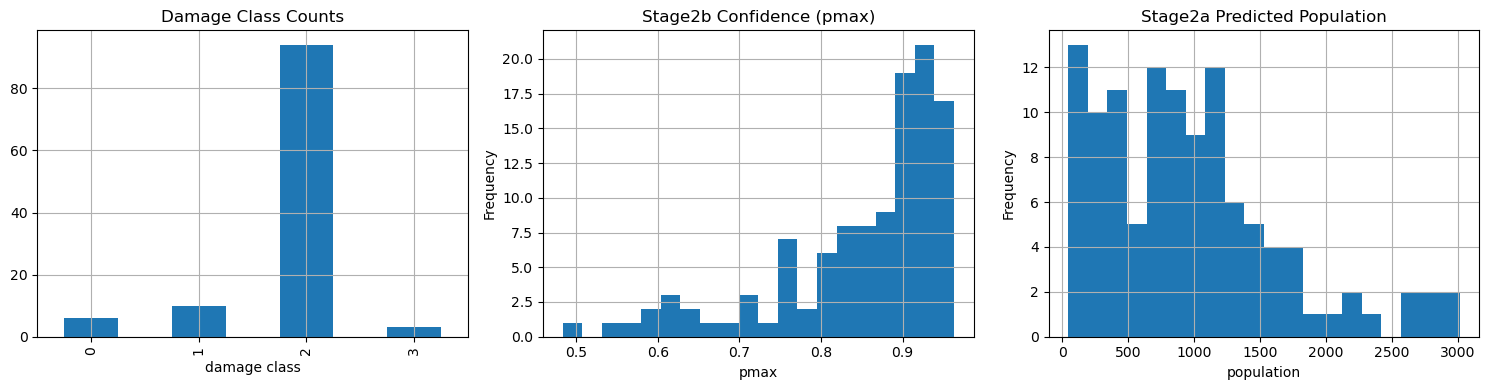

In [20]:
# --- 9) Distributional diagnostics ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

if "stage2b_pred_damage_class" in df.columns:
    damage = df["stage2b_pred_damage_class"].astype(str)
    damage = damage[damage != ""]
    damage.value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Damage Class Counts")
    axes[0].set_xlabel("damage class")

if "stage2b_pmax" in df.columns:
    pd.to_numeric(df["stage2b_pmax"], errors="coerce").dropna().plot(kind="hist", bins=20, ax=axes[1], title="Stage2b Confidence (pmax)")
    axes[1].set_xlabel("pmax")

if "stage2a_pred_population" in df.columns:
    pd.to_numeric(df["stage2a_pred_population"], errors="coerce").dropna().plot(kind="hist", bins=20, ax=axes[2], title="Stage2a Predicted Population")
    axes[2].set_xlabel("population")

plt.tight_layout()
plt.show()

### Result Discussion: Distribution Diagnostics

The distribution plots provide a quick structural sanity check for this case study. Damage predictions are concentrated in a subset of classes, confidence values are generally high but not saturated, and Stage 2a exposure estimates span a broad range.

This combination is consistent with a workable inference run: the model is not collapsing to a single confidence value, while still identifying a dominant damage pattern for this specific tile.

### Uncertainty-Centered Case Review

Top uncertain instances and sample overlays are presented below, linking numeric uncertainty indicators back to localized image evidence.

## Operational Interpretation Rules (Action-Oriented)

The synthesis outputs are intended for triage-style decision support. A practical rule set for this notebook's outputs is:

- **High impact + high confidence** (high severity/exposure, high `pmax`, low entropy): act early; prioritize response.
- **High impact + high uncertainty** (high severity/exposure, low margin/high entropy/variance): prioritize verification first, then action.
- **Low impact + low confidence**: defer immediate intervention, monitor, and re-check with additional context.
- **Cross-stage disagreement** (weak Stage 1 or Stage 2a confidence plus uncertain Stage 2b): route to analyst review queue.

This rule set is a workflow guide, not a substitute for policy judgment; high-stakes usage should retain human oversight.

Top uncertain instances (first 20):


,instance_id,tile_id,stage2b_pred_damage_class,stage2b_pmax,stage2b_entropy,stage2b_var_expected_severity_weighted,stage1_sam3_confidence,stage2a_pred_population,stage2a_pred_type_class,stage2a_pred_type_conf
0,9a52dad5-5471-430e-873f-fe01b048f9bd,nepal-flooding_00000408,2,0.626157,0.981120,0.088681,0.537324,2775.129395,commercial,0.850954
1,a5d8a076-6393-4f5c-9e18-8d2bfb47e5a0,nepal-flooding_00000408,2,0.601902,0.967076,0.011287,0.727723,1144.960815,commercial,0.609732
2,2b5f0eac-e652-4fad-a425-aa873544c34f,nepal-flooding_00000408,1,0.624434,0.924669,0.016329,0.558650,116.156059,institutional,0.523553
3,07181554-41c4-461d-9279-2634787ff764,nepal-flooding_00000408,2,0.642152,0.915487,0.118797,0.611485,1786.849121,commercial,0.761535
4,b156137f-f197-4347-82fb-aa23a098f58d,nepal-flooding_00000408,2,0.709753,0.886693,0.018746,0.503952,121.821358,institutional,0.596623
5,84a428de-7711-4f74-b211-38316cf71f09,nepal-flooding_00000408,1,0.591081,0.857761,0.027348,0.699470,679.988403,commercial,0.517448
6,c6fe7838-b26b-4cec-a84e-dc4bf7e4c295,nepal-flooding_00000408,2,0.672722,0.854492,0.079666,0.643273,1094.192993,commercial,0.645065
7,85db9a59-f54d-4225-9a2f-99535eb6b6d0,nepal-flooding_00000408,2,0.537775,0.839967,0.087797,0.515266,1120.065308,commercial,0.791614
8,7768a723-927c-457a-a1b0-55a8bae8866d,nepal-flooding_00000408,2,0.739302,0.839624,0.087020,0.711407,1216.048706,commercial,0.725024
9,c0c1187c-af49-418e-ab30-017a99c22bee,nepal-flooding_00000408,1,0.483375,0.834087,0.009041,0.775628,234.757294,commercial,0.495098


overlay files found: 100


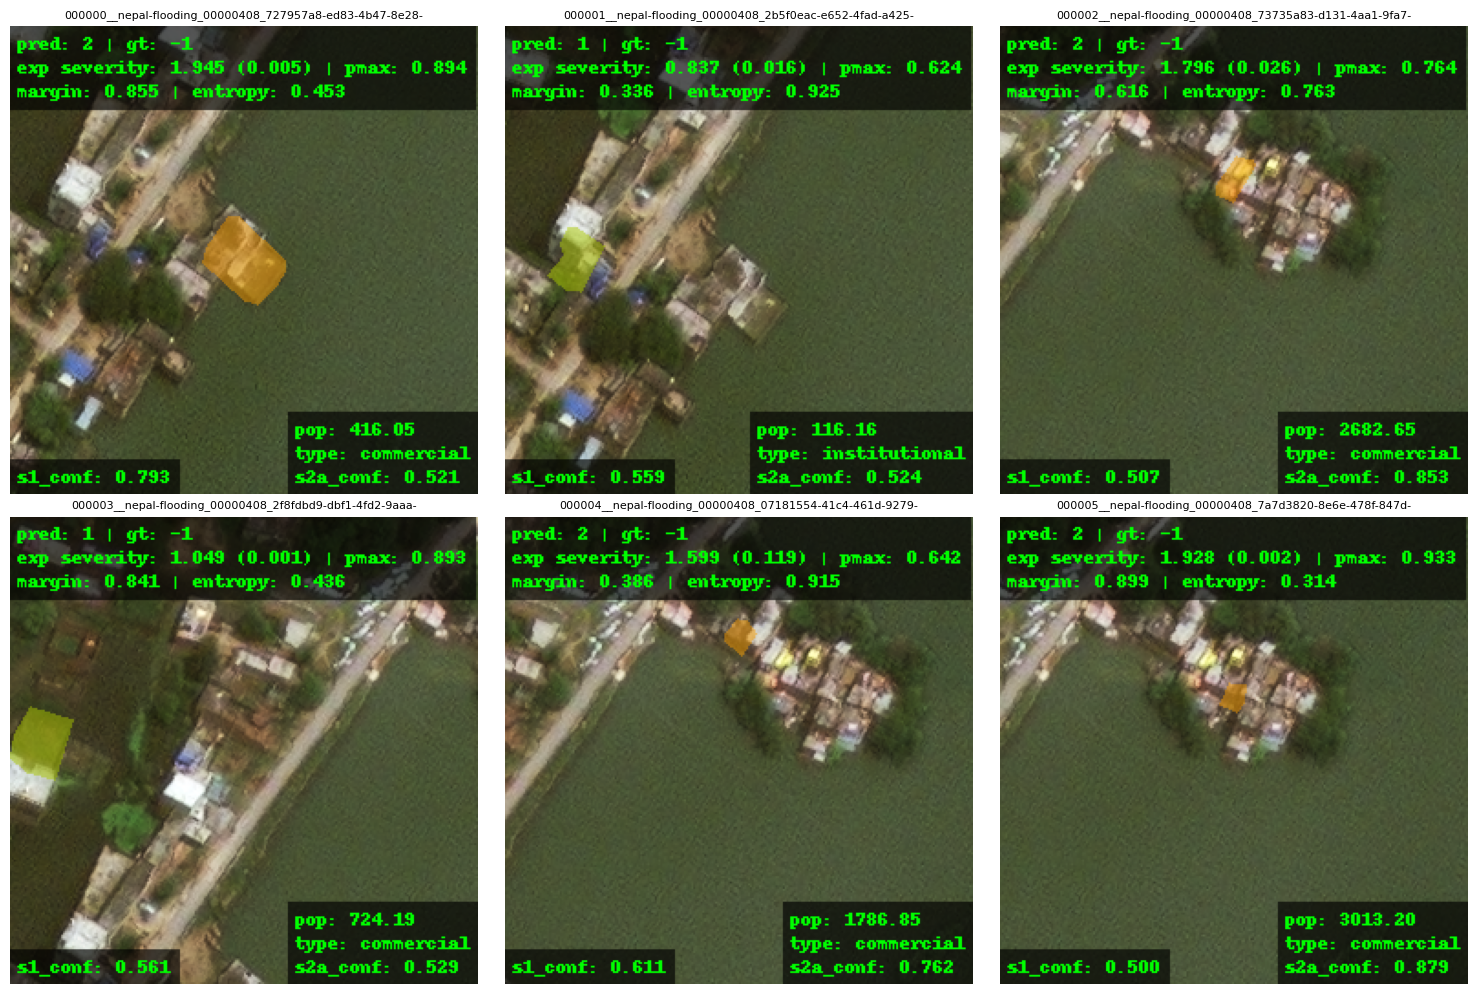

In [21]:
# --- 10) Uncertainty table + overlay preview ---
preview_cols = [
    "instance_id",
    "tile_id",
    "stage2b_pred_damage_class",
    "stage2b_pmax",
    "stage2b_entropy",
    "stage2b_var_expected_severity_weighted",
    "stage1_sam3_confidence",
    "stage2a_pred_population",
    "stage2a_pred_type_class",
    "stage2a_pred_type_conf",
]
cols = [c for c in preview_cols if c in df_unc.columns]
print("Top uncertain instances (first 20):")
display(df_unc[cols].head(20))

all_png = sorted(vis_dir.glob("*.png"))
assert len(all_png) > 0, f"No overlay images found in {vis_dir}"
img_paths = all_png[:6]
print("overlay files found:", len(all_png))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for ax, p in zip(axes, img_paths):
    im = Image.open(p)
    ax.imshow(im)
    ax.set_title(p.name[:56], fontsize=8)
    ax.axis("off")
for ax in axes[len(img_paths):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Instance-Level Interpretation of Predictions

Each panel should be read as a joint evidence unit: `pred` and `exp severity` indicate damage level, `pmax`/`margin`/`entropy` indicate confidence structure, `pop` represents exposure (Stage 2a), and `s1_conf`/`s2a_conf` provide upstream reliability context.

In the first row, **top-left** (`pred=2`, `exp severity=1.945`, `pmax=0.894`, `margin=0.855`, `entropy=0.453`, `pop=416`) is a high-confidence major-damage case with moderate exposure, making it a **Priority 1** candidate because inundation and contextual cues appear coherent. **Top-middle** (`pred=1`, `exp severity=0.337`, `pmax=0.624`, `margin=0.336`, `entropy=0.925`, `pop=116`) shows low severity, low exposure, and high ambiguity, so it fits **Priority 3-4** (low impact, verify only if resources allow). **Top-right** (`pred=2`, `exp severity=1.796`, `pmax=0.764`, `margin=0.616`, `entropy=0.763`, `pop=2682`) combines high exposure and strong damage under moderate confidence, placing it in **Priority 1-2**.

In the second row, **bottom-left** (`pred=1`, `exp severity=1.049`, `pmax=0.893`, `margin=0.841`, `entropy=0.436`, `pop=724`) is a borderline minor/major case but with high-confidence minor assignment, so it is best treated as **mid priority**. **Bottom-middle** (`pred=2`, `exp severity=1.599`, `pmax=0.642`, `margin=0.386`, `entropy=0.915`, `pop=1786`) has high impact potential but substantial uncertainty; this is a **Priority 2** case that should be verified before decisive action. **Bottom-right** (`pred=2`, `exp severity=1.928`, `pmax=0.933`, `margin=0.899`, `entropy=0.314`, `pop=3013`) is the strongest high-impact profile in the sample (very high exposure + very confident major damage), making it a clear **Priority 1** instance.

Across panels, four patterns are consistent: (1) impact is driven by **exposure x damage**, not damage alone; (2) high-entropy/low-margin predictions are useful flags for analyst review rather than model failure; (3) neighborhood context appears to contribute meaningfully in dense flooded clusters; and (4) exposure variation (~100 to ~3000 in this sample) materially changes triage priority even when predicted damage class is similar.

Overall, the outputs support a practical decision rule: use damage-exposure combination to rank consequence, then use uncertainty to decide whether to act immediately or verify first.

## Conclusion

### Impact Potential and Real-World Use Cases
This notebook delivers a complete building-instance disaster impact workflow that can support policy, operations, and research. By combining instance extraction, exposure proxy estimation, and calibrated damage uncertainty, the framework moves beyond coarse maps toward decision-support-ready outputs.

**Informing Disaster Risk Reduction and Response**
Instance-level damage and uncertainty can guide triage workflows by prioritizing locations with both high predicted severity and high confidence, while routing ambiguous cases to human review. This supports more transparent and auditable emergency decision pipelines.

**Targeted Infrastructure and Resilience Planning**
Merged outputs can identify building clusters where potential damage and exposure are both elevated, helping planners prioritize inspections, mitigation investments, and resilience interventions at finer spatial scales than area-level summaries.

**Socioeconomic and Humanitarian Targeting**
Although Stage 2a outputs are proxy estimates, they provide a practical signal for exposure-aware prioritization when merged with damage predictions. This can support NGOs and public agencies in resource allocation when rapid, building-level situational awareness is needed.

**Operational AI with Interpretable Evidence**
The uncertainty-ranked table and overlay products provide direct visual context for each prediction, improving interpretability and making model outputs more usable in analyst-in-the-loop environments.

### Next Steps and Potential Improvements
- Expand multi-event and multi-region validation to quantify generalization and domain-shift behavior more rigorously.
- Improve Stage 2a robustness by recalibration or region-adaptive fine-tuning where representative labels are available.
- Add explicit quality-control checks for artifact integrity (e.g., checkpoint validation, schema checks) as first-class notebook diagnostics.
- Introduce uncertainty-aware decision thresholds and abstention policies tailored to specific operational contexts.
- Evaluate lightweight acceleration options for Stage 1 on CPU-constrained sessions (tiling strategy, caching, or staged reuse).
- Extend synthesis outputs into downstream policy/operations dashboards for repeatable cross-event comparison.

### Limitations
Current results are model-derived estimates and should not be treated as ground truth without contextual validation. Performance may vary by geography, hazard characteristics, and imaging conditions; therefore, high-stakes usage should retain human oversight and uncertainty-aware review.

For comparative studies, rerun this workflow across multiple tiles/events and summarize aggregated uncertainty-aware metrics rather than relying on a single case study.

---

# Addendum — 2025 LA Wildfire Deployment

This section presents **pre-computed results** from applying the full Instance Impact pipeline to the 2025 Southern California Wildfires — a real operational deployment at scale.

| Attribute | Value |
|---|---|
| **Area** | ~197 km² across Los Angeles County |
| **Imagery** | Maxar OpenData satellite (pre-fire + 4 post-fire dates: Jan 10/14/15/18 2025) |
| **Grid** | 295 cells × 600 m × 600 m |
| **Buildings detected** | 21,797 (Stage 1 SAM3) across 120 cells; 175 cells had no detectable structures |
| **Damage method** | Coverage-aware majority vote across valid post-disaster dates |
| **Model** | Same ensemble as Part 1 — zero-shot transfer (trained on xBD floods, applied to wildfire) |

> **Note:** Results are loaded from pre-computed files bundled in this repository (`la_fire_results/`).
> No inference is re-run in this section.


## Live Mini Demo — Cell 00507, Eaton Fire Area

To show the pipeline running on **real LA wildfire imagery**, we run all three stages live on a single 600 m grid cell — **cell 00507** in Altadena — using the **January 15, 2025** post-disaster acquisition (8 days after the Eaton Fire ignition).

The same code from **The Pipeline** section above is used without modification. Only the input image pair changes.

> **Expected runtime:** ~2–4 minutes on GPU (Stage 1 ~30 s, shared subimages ~60 s, Stage 2a+2b ~30 s).

In [ ]:
LA_FIRE_DIR = PACKAGE_ROOT / "la_fire_results"
assert LA_FIRE_DIR.exists(), f"la_fire_results/ not found at {LA_FIRE_DIR}"

# ── Mini LA fire demo: cell_00507, post-date 2025-01-15 ─────────────────────
# Images are bundled in la_fire_results/demo_cell_00507/ (26 MB total).

DEMO_DIR  = LA_FIRE_DIR / "demo_cell_00507"
DEMO_PRE  = DEMO_DIR / "cell_00507_pre.tif"
DEMO_POST = DEMO_DIR / "cell_00507_post_20250115.tif"
DEMO_RUN  = _nb_dir / "runs" / "la_fire_demo_cell_00507"

assert DEMO_PRE.exists(),  f"Missing demo image: {DEMO_PRE}"
assert DEMO_POST.exists(), f"Missing demo image: {DEMO_POST}"
DEMO_RUN.mkdir(parents=True, exist_ok=True)

# Stage path variables — mirrors the main pipeline section
demo_tile_id   = DEMO_PRE.stem          # "cell_00507_pre"
demo_pair_dir  = DEMO_RUN / "pair_inputs"
demo_pair_dir.mkdir(parents=True, exist_ok=True)

# Symlink images with the _pre_disaster / _post_disaster suffix the pipeline expects
demo_pre_link  = demo_pair_dir / f"{demo_tile_id}_pre_disaster.png"
demo_post_link = demo_pair_dir / f"{demo_tile_id}_post_disaster.png"
for dst, src in [(demo_pre_link, DEMO_PRE), (demo_post_link, DEMO_POST)]:
    if dst.exists() or dst.is_symlink():
        dst.unlink()
    dst.symlink_to(src.resolve())

demo_stage1_out   = DEMO_RUN / "stage1"
demo_shared_out   = DEMO_RUN / "shared_instances_r48"
demo_s2a_input    = DEMO_RUN / "stage2a_infer_input.csv"
demo_s2a_out      = DEMO_RUN / "stage2a_predictions.csv"
demo_s2b_out      = DEMO_RUN / "stage2b_ensemble.jsonl"
demo_presented    = DEMO_RUN / "instance_results_presented.csv"
demo_uncertain    = DEMO_RUN / "instance_results_top_uncertain.csv"
demo_vis_dir      = DEMO_RUN / "vis_instance_level"

print(f"Pre image:  {DEMO_PRE.name}  ({DEMO_PRE.stat().st_size/1e6:.0f} MB)")
print(f"Post image: {DEMO_POST.name} ({DEMO_POST.stat().st_size/1e6:.0f} MB)")
print(f"Run dir:    {DEMO_RUN}")


In [ ]:
# Stage 1 — SAM3 building instance detection on the pre-disaster image
run_step(
    [
        PYTHON_BIN,
        PACKAGE_ROOT / "stage1/SAM3_Final_20260226/scripts/run_sam3_building_infer.py",
        "--input",        demo_pair_dir,
        "--output",       demo_stage1_out,
        "--pattern",      f"{demo_tile_id}_pre_disaster.png",
        "--max-images",   "1",
        "--prompt",       "building",
        "--min-size",     "30",
        "--output-style", "notebook",
        "--batch-size",   "1",
        "--device",       STAGE1_DEVICE,
        "--backend",      "transformers",
        "--tile-size",    "512",
        "--overlap",      "64",
    ],
    "Stage 1: Building Detection — cell_00507",
)
demo_label_dir = demo_stage1_out / "labels"


In [ ]:
# Shared subimage generation — crops each detected building from pre + post imagery
run_step(
    [
        PYTHON_BIN,
        PACKAGE_ROOT / "scripts/generate_shared_instance_subimages.py",
        "--stage1_labels_dir", demo_label_dir,
        "--pre_images_dir",    demo_pair_dir,
        "--post_images_dir",   demo_pair_dir,
        "--out_root",          demo_shared_out,
        "--crop_size",         "256",
        "--ring_radius_px",    "48",
        "--strict_images",
        "--num_workers",       "4",
        "--chunk_size",        "100",
        "--log_every",         "50",
    ],
    "Shared Subimage Generation — cell_00507",
)
demo_shared_csv = demo_shared_out / "shared_instance_samples.csv"


In [ ]:
# Stage 2a — exposure type classification
run_step(
    [
        PYTHON_BIN,
        PACKAGE_ROOT / "scripts/build_stage2a_infer_csv.py",
        "--shared_csv", demo_shared_csv,
        "--out_csv",    demo_s2a_input,
        "--crop_col",   "pre_crop",
        "--mask_col",   "mask_M",
    ],
    "Stage 2a: Build Inference CSV",
)
run_step(
    [
        PYTHON_BIN,
        PACKAGE_ROOT / "scripts/infer_stage2a.py",
        "--input_csv",     demo_s2a_input,
        "--ckpt",          PACKAGE_ROOT / "models/stage2a/stage2a_best_model.pt",
        "--out_csv",       demo_s2a_out,
        "--batch_size",    "4",
        "--num_workers",   "4",
        "--device",        STAGE_DEVICE,
        "--print_examples", "5",
    ],
    "Stage 2a: Exposure Inference — cell_00507",
)


In [ ]:
# Stage 2b — calibrated ensemble damage classification
run_step(
    [
        PYTHON_BIN,
        PACKAGE_ROOT / "scripts/infer_stage2_ensemble.py",
        "--csv",               demo_shared_csv,
        "--ckpts",             "models/stage2b/inference0.7273.pt,"
                               "models/stage2b/inference0.7066_seed9999.pt,"
                               "models/stage2b/inference0.7034_seed7777.pt",
        "--configs",           "configs/stage2b/run019_seed2025_train_config.json,"
                               "configs/stage2b/seed9999_train_config.json,"
                               "configs/stage2b/seed7777_train_config.json",
        "--weights",           "4,3,2",
        "--calibration_dirs",  "calibration/calibration_run019_r48,"
                               "calibration/calibration_seed9999_r48,"
                               "calibration/calibration_seed7777_r48",
        "--calibration_method", "temperature",
        "--out_jsonl",         demo_s2b_out,
        "--batch_size",        "2",
        "--num_workers",       "4",
        "--device",            STAGE_DEVICE,
        "--print_examples",    "5",
        "--log_every_steps",   "20",
    ],
    "Stage 2b: Ensemble Damage Inference — cell_00507",
)


In [ ]:
# Multi-date aggregation using pre-computed Stage 2b outputs for all 4 post-disaster dates.
# These were generated with consistent building IDs from the full HPC run.
# Note: the live Stage 2b run above used a fresh Stage 1 detection (new building IDs),
# so its outputs cannot be cross-aggregated with the pre-bundled dates. The live run
# is shown separately below; this cell aggregates the pre-bundled set for the 4-date summary.

import shutil

MULTIDATE_DIR = DEMO_DIR / "multidate_inputs"
demo_dates_root = DEMO_RUN / "dates"

# Copy all 4 pre-bundled dates
for date in ["20250110", "20250114", "20250115", "20250118"]:
    dst = demo_dates_root / date
    dst.mkdir(parents=True, exist_ok=True)
    for fname in [f"stage2b_{date}.jsonl", "quality_metrics.json", "shared_for_date.csv"]:
        shutil.copy(MULTIDATE_DIR / "dates" / date / fname, dst / fname)

demo_m2b_jsonl = DEMO_RUN / "m2b_aggregated.jsonl"
demo_m2b_csv   = DEMO_RUN / "m2b_aggregated.csv"

run_step(
    [
        PYTHON_BIN,
        PACKAGE_ROOT / "scripts/aggregate_multidate_predictions.py",
        "--cell_run_dir", DEMO_RUN,
        "--out_jsonl",    demo_m2b_jsonl,
        "--out_csv",      demo_m2b_csv,
    ],
    "Multi-Date Aggregation: Coverage-Aware Majority Vote (4 pre-bundled dates)",
)


In [ ]:
# Live Stage 2b results — cell_00507, post-date 2025-01-15
# (155 buildings from this session's Stage 1 detection)
import json
import matplotlib.pyplot as plt
from collections import Counter

rows_live = []
with open(demo_s2b_out) as f:
    for line in f:
        if line.strip():
            rows_live.append(json.loads(line))

DAMAGE_CLASS_LABELS = {0: "No damage", 1: "Minor", 2: "Major", 3: "Destroyed"}
DAMAGE_COLORS_INT   = {0: "#2ecc71", 1: "#f39c12", 2: "#e67e22", 3: "#e74c3c"}

counts_live = Counter(int(r["y_pred_ensemble"]) for r in rows_live)
print(f"cell_00507 — live (2025-01-15)  |  {len(rows_live):,} buildings")
print()
for cls in sorted(counts_live):
    n = counts_live[cls]
    print(f"  {DAMAGE_CLASS_LABELS.get(cls,'?'):<20} {n:>4}  ({n/len(rows_live)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(7, 4))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
keys = sorted(counts_live.keys())
bars = ax.bar(
    [DAMAGE_CLASS_LABELS.get(k, str(k)) for k in keys],
    [counts_live[k] for k in keys],
    color=[DAMAGE_COLORS_INT.get(k, "#aaa") for k in keys],
    edgecolor="#ccc", linewidth=0.5,
)
for bar, k in zip(bars, keys):
    v = counts_live[k]
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(v), ha="center", va="bottom", fontsize=9, color="black")
ax.set_title("Cell 00507 — Live Damage Results (2025-01-15)",
             color="black", fontsize=10)
ax.set_ylabel("Buildings", color="black")
ax.tick_params(colors="black")
for spine in ax.spines.values():
    spine.set_edgecolor("#aaa")
plt.tight_layout()
plt.show()


In [ ]:
# Satellite overlay: SAM3 building polygons colored by damage predictions
# Uses the pre-computed polygon data (full 365-building detection from the production run)
# overlaid on the Jan 15 post-disaster image — matching the pre-made QC overlays.
import json, csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from PIL import Image
from shapely import wkt as shapely_wkt

DATE = "20250115"
date_dir = MULTIDATE_DIR / "dates" / DATE

# Load pre-computed Stage 2b predictions for Jan 15
uid_to_class = {}
with open(date_dir / f"stage2b_{DATE}.jsonl") as f:
    for line in f:
        if line.strip():
            obj = json.loads(line)
            uid_to_class[obj["bldg_uid"]] = int(obj["y_pred_ensemble"])

# Load polygon WKTs (pixel space) from shared_for_date.csv
uid_to_wkt = {}
with open(date_dir / "shared_for_date.csv") as f:
    for row in csv.DictReader(f):
        uid_to_wkt[row["bldg_uid"]] = row.get("polygon_wkt_xy_pre", "")

# Load post-disaster image as background
img_arr = np.array(Image.open(DEMO_POST).convert("RGB"))
img_h, img_w = img_arr.shape[:2]

CLASS_COLORS = {0: "#2ecc71", 1: "#f39c12", 2: "#e67e22", 3: "#e74c3c", -1: "#95a5a6"}
CLASS_LABELS = {0: "No damage", 1: "Minor", 2: "Major", 3: "Destroyed", -1: "Not identifiable"}

fig, ax = plt.subplots(figsize=(10, 10))
fig.patch.set_facecolor("white")
ax.imshow(img_arr, origin="upper")

drawn = Counter()
for uid, cls in uid_to_class.items():
    wkt = uid_to_wkt.get(uid, "")
    if not wkt:
        continue
    try:
        geom = shapely_wkt.loads(wkt)
    except Exception:
        continue
    # Skip out-of-range polygons (coordinate system artefacts)
    b = geom.bounds
    if b[0] < -10 or b[2] > img_w + 10 or b[1] < -10 or b[3] > img_h + 10:
        continue
    color = CLASS_COLORS.get(cls, "#aaa")
    for poly in (geom.geoms if hasattr(geom, "geoms") else [geom]):
        if poly.is_empty or poly.area < 4:
            continue
        xs, ys = poly.exterior.xy
        ax.fill(xs, ys, alpha=0.45, color=color)
        ax.plot(xs, ys, color=color, linewidth=0.9, alpha=0.9)
    drawn[cls] += 1

handles = [mpatches.Patch(color=CLASS_COLORS[k], label=CLASS_LABELS[k])
           for k in sorted(drawn.keys())]
ax.legend(handles=handles, loc="lower left", facecolor="white", fontsize=9,
          title="Damage class (2025-01-15)", title_fontsize=9, edgecolor="#aaa")
ax.set_title(
    f"Cell 00507 — {sum(drawn.values())} buildings colored by damage class\n"
    "Post-event: 2025-01-15",
    fontsize=11, color="black", pad=10,
)
ax.set_xlim(0, img_w); ax.set_ylim(img_h, 0)
ax.axis("off")
plt.tight_layout()
plt.show()


## Pre-Computed Results

Rather than re-running the full multi-date pipeline live (which requires ~5 TB of Maxar imagery
and ~6 hours of GPU time), this section loads results that were pre-computed on the TAMU HPC cluster.
All data is bundled in `la_fire_results/` at the same directory as this notebook — no external
downloads are needed.

The **sample dataset** covers the 5 cells with the highest fraction of damaged buildings
(cells 00524, 00495, 00516, 00507, 00506), selected from 120 cells across ~197 km² of LA County.
The full 21,797-building dataset statistics are embedded as constants in the damage distribution analysis below.

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import json

# la_fire_results/ is bundled at the same level as this notebook
LA_FIRE_DIR = PACKAGE_ROOT / "la_fire_results"
assert LA_FIRE_DIR.exists(), f"la_fire_results/ not found at {LA_FIRE_DIR}"

# Load sample: top-5 most-damaged cells, 2,067 buildings
df_la = pd.read_csv(LA_FIRE_DIR / "sample_buildings.csv")
print(f"Sample dataset: {len(df_la):,} buildings across {df_la['cell_id'].nunique()} cells")
print(f"Cells: {sorted(df_la['cell_id'].unique())}")


## Damage Distribution

**Coverage-Aware Majority Vote** is the aggregation method used throughout.
For each building, predictions from up to 5 post-disaster acquisition dates are aggregated:

- A date is **valid** if both tile-level and crop-level quality checks pass (no nodata strips)
- Buildings with 0 valid dates are classified as `unknown` (not forced to a damage label)
- The final label is the majority vote across valid dates only

This eliminates a systematic artifact present in simpler aggregations: blank post-disaster
satellite tiles (caused by imaging gaps over the fire area) were consistently predicted as
"destroyed" by the model, inflating destroyed counts by >16×. Multi-date aggregation removes all such artifacts.

The bar charts below compare the full 21,797-building dataset against the 5-cell sample.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Full-dataset summary (from damage_summary.md) ──────────────────────────
full_counts = {"No damage": 16246, "Minor": 4174, "Major": 39, "Destroyed": 93, "Unknown": 1245}
total = sum(full_counts.values())
print("Full dataset (21,797 buildings):")
for cls, n in full_counts.items():
    print(f"  {cls:<12} {n:>6,}  ({n/total*100:.1f}%)")

print()

# ── Sample subset (5 high-damage cells) ────────────────────────────────────
print("Sample subset (5 highest-damage cells):")
sample_counts = df_la["m2b_damage_label"].value_counts()
print(sample_counts.to_string())

# ── Side-by-side bar charts ─────────────────────────────────────────────────
COLORS = {"no_damage": "#2ecc71", "minor": "#f39c12", "major": "#e67e22", "destroyed": "#e74c3c", "unknown": "#95a5a6"}
LABELS = {"no_damage": "No damage", "minor": "Minor", "major": "Major", "destroyed": "Destroyed", "unknown": "Not identifiable"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor("white")

for ax, (title, counts) in zip(axes, [
    ("Full LA Fire Dataset (21,797 buildings)", full_counts),
    ("Sample: 5 High-Damage Cells (2,067 buildings)", sample_counts),
]):
    if hasattr(counts, "items"):
        keys = list(counts.keys())
        vals = [counts[k] for k in keys]
        colors = [COLORS.get(k.lower().replace(" ","_"), "#aaa") for k in keys]
        labels = [LABELS.get(k.lower().replace(" ","_"), k) for k in keys]
    else:
        keys = counts.index.tolist()
        vals = counts.values.tolist()
        colors = [COLORS.get(k, "#aaa") for k in keys]
        labels = [LABELS.get(k, k) for k in keys]
    bars = ax.bar(labels, vals, color=colors, edgecolor="#ccc", linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f"{v:,}", ha="center", va="bottom", color="black", fontsize=9)
    ax.set_facecolor("white")
    ax.tick_params(colors="black")
    ax.set_title(title, color="black", fontsize=11)
    ax.set_ylabel("Buildings", color="black")
    for spine in ax.spines.values():
        spine.set_edgecolor("#aaa")

plt.tight_layout()
plt.show()


## Spatial Maps — Altadena / Eaton Fire Area

Four map types generated from the full 21,797-building dataset using aggregated damage labels.


In [ ]:
from IPython.display import Image, display

map_dir = LA_FIRE_DIR / "maps"
maps_to_show = [
    ("building_damage_map_east.png",   "Building Damage Map — per building polygon, colored by damage class"),
    # ("damage_density_map_east.png",    "Damage Density — spatial hexbin concentration + major/destroyed overlay"),
    # ("per_cell_damage_pct_east.png",   "Per-Cell Damage % — circle per 600m cell, color = % minor+major"),
    # ("uncertainty_map_east.png",       "Prediction Stability — red = conflicting labels across post dates"),
]

for fname, caption in maps_to_show:
    print(f"\n{caption}")
    display(Image(filename=str(map_dir / fname), width=850))


## Spatial Footprint

Building polygons for the 5 highest-damage cells, colored by aggregated damage class.
Data is in WGS84 GeoJSON — a standard interoperable format (FAIR: Interoperable).


In [ ]:
import geopandas as gpd

DAMAGE_COLORS = {
    "no_damage": "#2ecc71",
    "minor":     "#f39c12",
    "major":     "#e67e22",
    "destroyed": "#e74c3c",
    "unknown":   "#95a5a6",
}
DAMAGE_LABELS = {
    "no_damage": "No damage",
    "minor":     "Minor",
    "major":     "Major",
    "destroyed": "Destroyed",
    "unknown":   "Not identifiable",
}

gdf = gpd.read_file(LA_FIRE_DIR / "sample_cells.geojson")
# 5 polygons have reprojection artifacts (lat ≈ 0 instead of ~34°N).
gdf = gdf[gdf.geometry.bounds.miny > 30].copy()
gdf["color"] = gdf["m2b_damage_label"].map(DAMAGE_COLORS).fillna("#aaa")

fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for label, color in DAMAGE_COLORS.items():
    sub = gdf[gdf["m2b_damage_label"] == label]
    if len(sub):
        sub.plot(ax=ax, color=color, linewidth=0.2, edgecolor="#aaa",
                 alpha=0.85, label=DAMAGE_LABELS[label])

# Annotate each cell with its ID at the centroid
for cell_id, group in gdf.groupby("cell_id"):
    cx = group.geometry.centroid.x.mean()
    cy = group.geometry.centroid.y.mean()
    ax.text(cx, cy, cell_id.replace("cell_", "Cell "),
            ha="center", va="center", fontsize=8, color="#222",
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.6, edgecolor="none"))

legend = ax.legend(title="Damage Class", facecolor="white",
                   labelcolor="black", title_fontsize=10, fontsize=9,
                   loc="lower left", edgecolor="#aaa")
legend.get_title().set_color("black")
ax.set_title(f"Building Damage — 5 High-Damage Cells ({len(gdf):,} buildings)",
             color="black", fontsize=12, pad=12)
ax.tick_params(colors="black")
ax.set_xlabel("Longitude", color="black")
ax.set_ylabel("Latitude", color="black")
for spine in ax.spines.values():
    spine.set_edgecolor("#aaa")
plt.tight_layout()
plt.show()

print(f"CRS: {gdf.crs}  |  Columns: {list(gdf.columns)}")


In [ ]:
from IPython.display import Image, display

# Satellite QC overlays: SAM3-detected building polygons coloured by damage class
# overlaid on post-event imagery for 3 of the 5 highest-damage cells.
# Green = no damage, amber = minor, orange = major, red = destroyed.
qc_dir = LA_FIRE_DIR / "qc_overlays"
qc_cells = [
    ("cell_00495_qc_m2b.png", "Cell 00495 — Altadena (high destroyed count)"),
    ("cell_00507_qc_m2b.png", "Cell 00507 — Eaton Fire core area"),
    ("cell_00524_qc_m2b.png", "Cell 00524 — Mixed damage zone"),
]
for fname, label in qc_cells:
    print(f"\n{label}")
    display(Image(filename=str(qc_dir / fname), width=750))


## Responsible Use — Domain Mismatch

The Stage-2b ensemble was **trained on flood events** from the xBD benchmark and applied
**zero-shot** to the 2025 LA wildfires. Key implications:

- **"Minor" damage** in wildfire context likely captures discoloration, ash deposits, and roof
  texture changes visible in satellite imagery — not the same as flood-inundated structure.
- **High inter-date instability (51%)** is expected: the model was not calibrated for wildfire
  spectral signatures, leading to inconsistent predictions across acquisition dates.
- **No model retraining** was performed. All results should be interpreted as a *baseline*
  capability demonstration, not a validated operational product.
- Future work: fine-tuning on wildfire-labeled imagery (e.g., FEMA damage surveys + Maxar imagery)
  would substantially improve calibration.


## Stage 1 Detection Benchmark

SAM3 text-prompted segmentation evaluated on the full xView2 test set (933 pre-disaster images, 8 disaster types):

| Metric | Score |
|--------|-------|
| Precision | 0.682 |
| Recall | 0.284 |
| F1 | 0.401 |
| Mean IoU (matched) | 0.759 |

High precision (0.682) means SAM3's detections are geometrically accurate; lower recall (0.284) reflects missed buildings in dense and rural scenes. The most relevant single-hazard reference is santa-rosa-wildfire (F1 = 0.547), which is the closest analog to the LA fire application.


---

## Data & Reproducibility

| FAIR Principle | Implementation |
|---|---|
| **Findable** | Code at [github.com/jikun-tamu/Instance-Impact-IGUIDE-SpatialAIChallenge2026](https://github.com/jikun-tamu/Instance-Impact-IGUIDE-SpatialAIChallenge2026). Data bundled in repo or generated by running this notebook. |
| **Accessible** | Single `git clone`. Model checkpoints are downloaded automatically from GitHub Releases. Maxar OpenData imagery (public). xBD training data publicly available from IEEE GRSS. |
| **Interoperable** | Outputs in GeoJSON (RFC 7946), CSV, PNG. Damage classes follow xView2 taxonomy. Polygons in WGS84 (EPSG:4326). |
| **Reusable** | Modular stages (Stage 1/2a/2b independent). Domain mismatch limitations stated. Calibration artifacts and configs bundled. |

To reproduce from scratch: `git clone` → set `HF_TOKEN` → run notebook top-to-bottom (checkpoints auto-download from GitHub Releases).
